In [2]:
import yaml
import numpy as np
import polars as pl
from tqdm import tqdm
import statsmodels.api as sm
from scipy.stats import spearmanr

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [3]:
# Configuration and paths
mac = 20

# Maximum number of top-ranked variants per annotation (None = no limit)
max_num_variants = None

# Initialize new annotation variable as None
new_anno_local = None

# Load annotation configuration
config_path = "/home/dnanexus/ukbgym/config_pheno.yaml"

with open(config_path) as f:
    config = yaml.safe_load(f)

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""plof""","""loftee_hc""","""#E31A1C""","""LOFTEE HC""",1
"""plof_consequences""","""consequence_frameshift_variant""","""#E31A1C""","""VEP Frameshift""",1
"""plof_consequences""","""consequence_stop_gained""","""#FB9A99""","""VEP Stop Gained""",1
"""plof_consequences""","""consequence_splice_donor_varia…","""#6A1B9A""","""VEP Splice Donor""",1
"""plof_consequences""","""consequence_splice_acceptor_va…","""#AB47BC""","""VEP Splice Acceptor""",1
…,…,…,…,…
"""vep_consequences""","""consequence_stop_lost""","""#FFB300""","""VEP Stop Lost""",1
"""vep_consequences""","""consequence_missense_variant""","""#1E90FF""","""VEP Missense""",1
"""vep_consequences""","""consequence_synonymous_variant""","""#C6DBEF""","""VEP Synonymous""",1


In [70]:
RAP_ANNO_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated"
LOCAL_ANNO_DIR = "/home/dnanexus/data_dir"

# ANNO_FILE = "annotations_fillna_ukbgym_with_mane.parquet"
ANNO_FILE = "annotations_with_all.parquet"

!dx download {RAP_ANNO_DIR}/{ANNO_FILE} -o {LOCAL_ANNO_DIR}/{ANNO_FILE}
anno = pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

regions_of_interest = ['ENSG00000130164']

anno = (
    anno
    .filter(
        # Filter to gene regions of interest
        (pl.col('region').is_in(regions_of_interest)),

        # Only SNPs
        # (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    .select(
        set(['id', 'region']).union(set(existing_annos))
    )
    .collect(engine='streaming')
    .unique()
)

anno

Error: path "/home/dnanexus/data_dir/annotations_with_all.parquet" already
exists but -f/--overwrite was not set


consequence_stop_gained,consequence_missense_variant,esmscoremissense,five_prime_utr_variant_consequence_uaug_lost,id,five_prime_utr_variant_consequence_uaug_gained,loftee_lc,delta_score,loftee_hc,consequence_start_lost,five_prime_utr_variant_consequence_ustop_lost,esm1b_llr,ted_domain,abexp_abs_max,abexp_min,revel_score,aparent2,bayes_del,low_complexity_domain,clinpred_score,consequence_splice_acceptor_variant,verphylop,encode_pels,region,absplice2_max,pangolin_score,five_prime_utr_variant_consequence_ustop_gained,relative_cds_position,mobi_curated_disorder_priority,encode_tf,am_pathogenicity,encode_dels,consequence_stop_lost,gpn_score,consequence_splice_donor_variant,consequence_synonymous_variant,cpt1_llr,polyphen,consequence_frameshift_variant,cadd_raw,encode_pls
i8,i8,f32,u8,str,u8,i8,f32,i8,i8,u8,f32,bool,f32,f32,f32,f32,f32,bool,f32,i8,f32,bool,str,f32,f32,u8,f32,bool,bool,f32,bool,i8,f32,i8,i8,f32,f32,i8,f32,bool
0,0,0.0,0,"""chr19:11127127:C:T""",0,0,0.0,0,0,0,0.0,false,0.005877,-0.005877,0.0,0.0,-0.249576,false,0.0,0,0.256,false,"""ENSG00000130164""",0.000033,0.0,0,0.0,false,false,0.0,false,0,-0.29,0,0,0.0,0.0,0,0.135378,false
0,0,0.0,0,"""chr19:11105898:TG:T""",0,0,0.0,0,0,0,0.0,false,0.0,0.0,0.0,0.0,-0.249576,false,0.0,0,0.129,false,"""ENSG00000130164""",0.0,0.0,0,0.0,false,false,0.0,false,0,-1.41,0,0,0.0,0.0,0,0.28051,false
0,0,0.0,0,"""chr19:11090332:C:G""",0,0,0.0,0,0,0,0.0,false,0.005877,-0.005877,0.0,0.0,-0.249576,false,0.0,0,-0.981,true,"""ENSG00000130164""",0.000033,0.0,0,0.0,false,false,0.0,false,0,-1.56,0,0,0.0,0.0,0,0.111267,false
0,0,0.0,0,"""chr19:11090090:C:G""",0,0,0.0,0,0,0,0.0,false,0.005877,-0.005877,0.0,0.0,-0.249576,false,0.0,0,-0.747,true,"""ENSG00000130164""",0.000033,0.0,0,0.0,false,false,0.0,false,0,-0.03,0,0,0.0,0.0,0,0.372432,false
0,0,0.0,0,"""chr19:11127834:A:G""",0,0,0.0,0,0,0,0.0,false,0.005679,-0.005679,0.0,0.0,-0.249576,false,0.0,0,0.431,false,"""ENSG00000130164""",0.000033,0.0,0,0.0,false,false,0.0,false,0,-1.38,0,0,0.0,0.0,0,0.173086,false
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0,0,0.0,0,"""chr19:11133327:C:G""",0,0,0.0,0,0,0,0.0,false,0.002741,0.002365,0.0,0.0,-0.249576,false,0.0,0,-1.617,false,"""ENSG00000130164""",0.000033,0.0,0,0.0,false,false,0.0,true,0,-0.52,0,0,0.0,0.0,0,-0.187668,false
0,0,0.0,0,"""chr19:11091252:G:C""",0,0,0.0,0,0,0,0.0,false,0.005679,-0.005679,0.0,0.0,-0.249576,false,0.0,0,1.144,true,"""ENSG00000130164""",0.000033,0.0,0,0.0,false,false,0.0,false,0,-1.51,0,0,0.0,0.0,0,0.247858,false
0,0,0.0,0,"""chr19:11124302:C:G""",0,0,0.0,0,0,0,0.0,false,0.005679,-0.005679,0.0,0.0,-0.249576,false,0.0,0,0.203,false,"""ENSG00000130164""",0.000033,0.0,0,0.0,false,false,0.0,false,0,0.09,0,0,0.0,0.0,0,0.435423,false


# Pheno scatter plot

In [64]:
# Get gene trait associations
RAP_DIR = 'project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results'

# ASSOC_FILE = 'loftee_mac20_associations_bh_corrected.parquet'
# ASSOC_FILE = 'regenie_127phenotypes_lofteeHC_mac20_EUR.parquet'
ASSOC_FILE = 'regenie_127phenotypes_lofteeHC_mac20_EUR_miss20per.parquet'

LOCAL_DIR = '/home/dnanexus/data_dir/'

!dx download {RAP_DIR}/{ASSOC_FILE} -o {LOCAL_DIR}

gene_trait_df = (
    pl.read_parquet(f'{LOCAL_DIR}/{ASSOC_FILE}')
    .filter(pl.col('pval_fdr')<=0.05)
    .select(['region', 'phenotype', 'pval_fdr'])
)

# CORR_FILE = 'regenie_127phenotypes_mac20_lofteeHC_EUR_correlations.parquet'
CORR_FILE = "regenie_127phenotypes_lofteeHC_mac20_EUR_miss20per_correlations.parquet"
!dx download {RAP_DIR}/{CORR_FILE} -o {LOCAL_DIR}

loftee_corrs = (
    pl.read_parquet(f'{LOCAL_DIR}/{CORR_FILE}')
    .with_columns(
        loftee_corr = pl.col('correlation'),
        loftee_corr_abs = pl.col('correlation').abs(),
        loftee_corr_dir = pl.col('correlation')/pl.col('correlation').abs(),
    )
    .select(['region', 'phenotype', 'loftee_corr', 'loftee_corr_abs', 'loftee_corr_dir']) 
)

gene_trait_df = (
    gene_trait_df
    .join(loftee_corrs, on=['region', 'phenotype'], how='inner')
    .drop_nans()
    .filter(
        pl.col('region')=='ENSG00000130164',
        pl.col('phenotype')=='ldl_direct_int',
    )
    # .sort('loftee_corr_abs', descending=True)
    # .unique(subset=["region"], keep="first", maintain_order=True)
)

gene_trait_df

Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_lofteeHC_mac20_EUR_
miss20per.parquet" already exists but -f/--overwrite was not set
Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_lofteeHC_mac20_EUR_
miss20per_correlations.parquet" already exists but -f/--overwrite was not set


region,phenotype,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir
str,str,f64,f64,f64,f64
"""ENSG00000130164""","""ldl_direct_int""",3.0392e-14,0.029721,0.029721,1.0


In [71]:
RAP_APPV_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/avg_pheno_per_var"
LOCAL_APPV_DIR = "/home/dnanexus/data_dir"

# APPV_FILE = "loftee_mac20_quant_pheno_assocs_EURunrelated_appv_percentiles.parquet"
# APPV_FILE = "quant_pheno_loftee_mac20_EURunrelated_miss20per_appv_percentiles_small.parquet"
APPV_FILE = "quant_pheno_INT_loftee_mac20_EURunrelated_miss20per_appv_small.parquet"

!dx download {RAP_APPV_DIR}/{APPV_FILE} -o {LOCAL_APPV_DIR}/{APPV_FILE}
pheno_appv = pl.scan_parquet(f"{LOCAL_APPV_DIR}/{APPV_FILE}")

# Filter to variants in annotation set and low MAC
anno_keys = anno.select(pl.col('id').unique()).lazy()

# Merge phenotype data and annotation data
pheno_appv = (
    pheno_appv
    .join(
        anno_keys, on='id', how='semi'
    )
    .join(
        gene_trait_df.select(pl.col('phenotype').unique()).lazy(), on='phenotype', how='semi'
    )
    .filter(
        (pl.col('n_individuals') <= mac)
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value', 'n_individuals']
    )
    .collect(engine='streaming')
)

pheno_appv

Error: path "/home/dnanexus/data_dir/quant_pheno_INT_loftee_mac20_EURunrelated
_miss20per_appv_small.parquet" already exists but -f/--overwrite was not set


id,phenotype,mean_pheno_value,n_individuals
str,str,f32,i32
"""chr19:11090408:C:A""","""ldl_direct_int""",0.998382,1
"""chr19:11138678:C:T""","""ldl_direct_int""",-0.619279,1
"""chr19:11098111:G:A""","""ldl_direct_int""",-0.018698,15
"""chr19:11090769:G:T""","""ldl_direct_int""",0.3455,19
"""chr19:11114379:T:C""","""ldl_direct_int""",-0.34552,1
…,…,…,…
"""chr19:11122927:C:T""","""ldl_direct_int""",-0.008554,1
"""chr19:11109993:G:A""","""ldl_direct_int""",0.643693,1
"""chr19:11133567:G:C""","""ldl_direct_int""",-0.493974,1


In [72]:
pheno_plot_df = (
    anno
    .join(
        pheno_appv, on='id', how='inner'
    )
)

pheno_plot_df

consequence_stop_gained,consequence_missense_variant,esmscoremissense,five_prime_utr_variant_consequence_uaug_lost,id,five_prime_utr_variant_consequence_uaug_gained,loftee_lc,delta_score,loftee_hc,consequence_start_lost,five_prime_utr_variant_consequence_ustop_lost,esm1b_llr,ted_domain,abexp_abs_max,abexp_min,revel_score,aparent2,bayes_del,low_complexity_domain,clinpred_score,consequence_splice_acceptor_variant,verphylop,encode_pels,region,absplice2_max,pangolin_score,five_prime_utr_variant_consequence_ustop_gained,relative_cds_position,mobi_curated_disorder_priority,encode_tf,am_pathogenicity,encode_dels,consequence_stop_lost,gpn_score,consequence_splice_donor_variant,consequence_synonymous_variant,cpt1_llr,polyphen,consequence_frameshift_variant,cadd_raw,encode_pls,phenotype,mean_pheno_value,n_individuals
i8,i8,f32,u8,str,u8,i8,f32,i8,i8,u8,f32,bool,f32,f32,f32,f32,f32,bool,f32,i8,f32,bool,str,f32,f32,u8,f32,bool,bool,f32,bool,i8,f32,i8,i8,f32,f32,i8,f32,bool,str,f32,i32
0,0,0.0,0,"""chr19:11127127:C:T""",0,0,0.0,0,0,0,0.0,false,0.005877,-0.005877,0.0,0.0,-0.249576,false,0.0,0,0.256,false,"""ENSG00000130164""",0.000033,0.0,0,0.0,false,false,0.0,false,0,-0.29,0,0,0.0,0.0,0,0.135378,false,"""ldl_direct_int""",0.552589,1
0,0,0.0,0,"""chr19:11105898:TG:T""",0,0,0.0,0,0,0,0.0,false,0.0,0.0,0.0,0.0,-0.249576,false,0.0,0,0.129,false,"""ENSG00000130164""",0.0,0.0,0,0.0,false,false,0.0,false,0,-1.41,0,0,0.0,0.0,0,0.28051,false,"""ldl_direct_int""",-0.237903,1
0,0,0.0,0,"""chr19:11090332:C:G""",0,0,0.0,0,0,0,0.0,false,0.005877,-0.005877,0.0,0.0,-0.249576,false,0.0,0,-0.981,true,"""ENSG00000130164""",0.000033,0.0,0,0.0,false,false,0.0,false,0,-1.56,0,0,0.0,0.0,0,0.111267,false,"""ldl_direct_int""",-1.034279,2
0,0,0.0,0,"""chr19:11090090:C:G""",0,0,0.0,0,0,0,0.0,false,0.005877,-0.005877,0.0,0.0,-0.249576,false,0.0,0,-0.747,true,"""ENSG00000130164""",0.000033,0.0,0,0.0,false,false,0.0,false,0,-0.03,0,0,0.0,0.0,0,0.372432,false,"""ldl_direct_int""",-0.010209,8
0,0,0.0,0,"""chr19:11127834:A:G""",0,0,0.0,0,0,0,0.0,false,0.005679,-0.005679,0.0,0.0,-0.249576,false,0.0,0,0.431,false,"""ENSG00000130164""",0.000033,0.0,0,0.0,false,false,0.0,false,0,-1.38,0,0,0.0,0.0,0,0.173086,false,"""ldl_direct_int""",0.492215,1
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0,0,0.0,0,"""chr19:11133327:C:G""",0,0,0.0,0,0,0,0.0,false,0.002741,0.002365,0.0,0.0,-0.249576,false,0.0,0,-1.617,false,"""ENSG00000130164""",0.000033,0.0,0,0.0,false,false,0.0,true,0,-0.52,0,0,0.0,0.0,0,-0.187668,false,"""ldl_direct_int""",-0.169152,4
0,0,0.0,0,"""chr19:11091252:G:C""",0,0,0.0,0,0,0,0.0,false,0.005679,-0.005679,0.0,0.0,-0.249576,false,0.0,0,1.144,true,"""ENSG00000130164""",0.000033,0.0,0,0.0,false,false,0.0,false,0,-1.51,0,0,0.0,0.0,0,0.247858,false,"""ldl_direct_int""",1.657449,2
0,0,0.0,0,"""chr19:11124302:C:G""",0,0,0.0,0,0,0,0.0,false,0.005679,-0.005679,0.0,0.0,-0.249576,false,0.0,0,0.203,false,"""ENSG00000130164""",0.000033,0.0,0,0.0,false,false,0.0,false,0,0.09,0,0,0.0,0.0,0,0.435423,false,"""ldl_direct_int""",0.880441,1


In [73]:
# Select annotation to plot
selected_annotation = 'am_pathogenicity'

# Look up color and label from config
_anno_row = anno_config_df.filter(pl.col('annotation') == selected_annotation)
anno_color = _anno_row['color'][0]
anno_label = _anno_row['label'][0]

print(f"Annotation: {selected_annotation} → {anno_label} (color: {anno_color})")

Annotation: am_pathogenicity → AlphaMissense (color: #feb72d)


In [79]:
pheno_plot_df.filter(pl.col(selected_annotation) != 0)

consequence_stop_gained,consequence_missense_variant,esmscoremissense,five_prime_utr_variant_consequence_uaug_lost,id,five_prime_utr_variant_consequence_uaug_gained,loftee_lc,delta_score,loftee_hc,consequence_start_lost,five_prime_utr_variant_consequence_ustop_lost,esm1b_llr,ted_domain,abexp_abs_max,abexp_min,revel_score,aparent2,bayes_del,low_complexity_domain,clinpred_score,consequence_splice_acceptor_variant,verphylop,encode_pels,region,absplice2_max,pangolin_score,five_prime_utr_variant_consequence_ustop_gained,relative_cds_position,mobi_curated_disorder_priority,encode_tf,am_pathogenicity,encode_dels,consequence_stop_lost,gpn_score,consequence_splice_donor_variant,consequence_synonymous_variant,cpt1_llr,polyphen,consequence_frameshift_variant,cadd_raw,encode_pls,phenotype,mean_pheno_value,n_individuals
i8,i8,f32,u8,str,u8,i8,f32,i8,i8,u8,f32,bool,f32,f32,f32,f32,f32,bool,f32,i8,f32,bool,str,f32,f32,u8,f32,bool,bool,f32,bool,i8,f32,i8,i8,f32,f32,i8,f32,bool,str,f32,i32
0,1,-10.993,0,"""chr19:11106616:T:C""",0,0,0.0,0,0,0,-11.763,true,0.122196,-0.122196,0.919,0.0,0.546139,false,0.995066,0,8.862,false,"""ENSG00000130164""",0.000338,0.0,0,0.29,true,false,0.8602,true,0,-7.95,0,0,0.639466,0.998,0,3.950893,false,"""ldl_direct_int""",0.783216,1
0,1,-5.002,0,"""chr19:11129609:A:T""",0,0,0.0,0,0,0,-8.409,false,0.094163,-0.094163,0.642,0.0,0.057471,false,0.871801,0,2.049,false,"""ENSG00000130164""",0.000428,0.0,0,0.96,false,false,0.2976,false,0,-6.88,0,0,0.128851,0.483,0,4.177474,false,"""ldl_direct_int""",-0.476071,7
0,1,-5.324,0,"""chr19:11116156:T:C""",0,0,0.01,0,0,0,-5.367,true,0.069889,-0.069889,0.38,0.0,-0.13222,false,0.651199,0,2.012,false,"""ENSG00000130164""",0.000437,0.01,0,0.64,false,false,0.1141,true,0,-6.22,0,0,0.112493,0.955,0,2.611007,false,"""ldl_direct_int""",-1.661508,1
0,1,-10.813,0,"""chr19:11129531:G:A""",0,0,0.05,0,0,0,-11.584,false,0.05204,-0.05204,0.409,0.0,0.005695,true,0.67961,0,0.12,false,"""ENSG00000130164""",0.000355,0.01,0,0.93,false,false,0.4479,true,0,-6.05,0,0,0.592467,0.074,0,1.82004,false,"""ldl_direct_int""",1.697069,1
0,1,-7.427,0,"""chr19:11116963:A:G""",0,0,0.0,0,0,0,-11.572,true,0.075547,-0.075547,0.481,0.0,-0.160904,false,0.40223,0,0.572,false,"""ENSG00000130164""",0.006645,0.03,0,0.7,false,false,0.2501,true,0,-5.89,0,0,0.325816,0.895,0,2.634839,false,"""ldl_direct_int""",-0.382454,1
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0,1,-10.282,0,"""chr19:11111586:A:C""",0,0,0.0,0,0,0,-11.882,false,0.070551,-0.070551,0.754,0.0,0.2964,false,0.934857,0,8.487,true,"""ENSG00000130164""",0.000321,0.0,0,0.44,true,false,0.5188,false,0,-6.32,0,0,0.516438,0.961,0,4.130316,false,"""ldl_direct_int""",0.641495,12
0,1,-8.882,0,"""chr19:11116914:C:G""",0,0,0.28,0,0,0,-10.98,true,0.12083,-0.12083,0.746,0.0,0.3994,false,0.97822,0,0.182,false,"""ENSG00000130164""",0.000437,0.07,0,0.68,false,false,0.9393,true,0,-9.88,0,0,0.61529,0.984,0,3.21911,false,"""ldl_direct_int""",-0.229574,11
0,1,-11.418,0,"""chr19:11113322:A:G""",0,0,0.0,0,0,0,-10.176,true,0.089759,-0.089759,0.818,0.0,0.178304,false,0.963392,0,5.368,false,"""ENSG00000130164""",0.000387,0.0,0,0.48,false,false,0.6204,false,0,-7.34,0,0,0.575439,0.922,0,4.572957,true,"""ldl_direct_int""",2.373857,1


Spearman ρ = 0.066 (p = 3.21e-13)


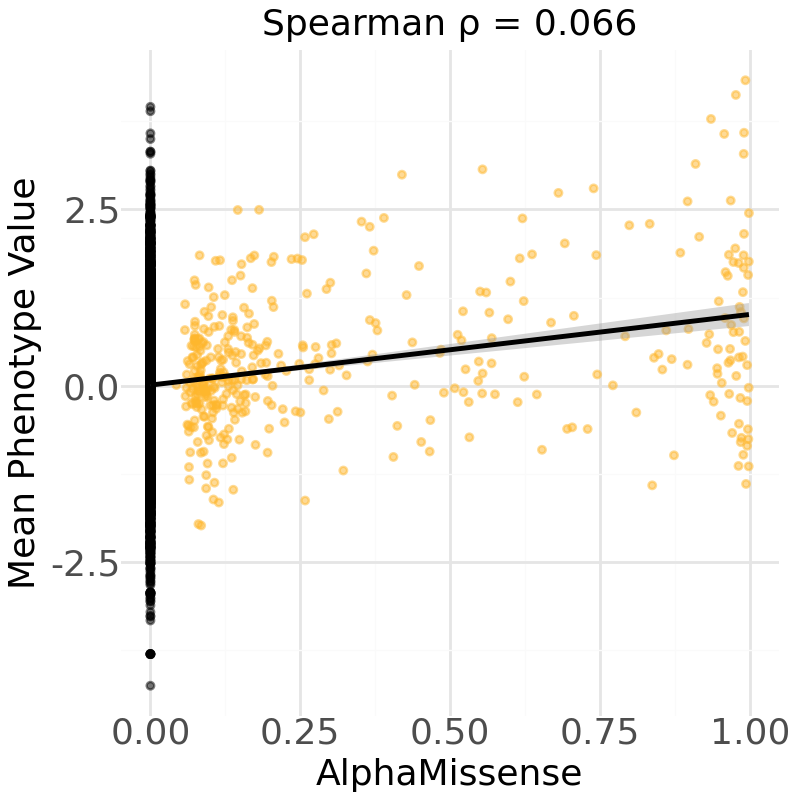

In [77]:
scatter_df = (
    pheno_plot_df
    .select(['id', selected_annotation, 'mean_pheno_value'])
    .drop_nulls()
    .with_columns(
        is_scored = pl.when(pl.col(selected_annotation) != 0)
            .then(pl.lit('Scored'))
            .otherwise(pl.lit('Not scored'))
    )
)

# Spearman correlation
rho, pval = spearmanr(
    scatter_df[selected_annotation].to_numpy(),
    scatter_df['mean_pheno_value'].to_numpy()
)
print(f"Spearman ρ = {rho:.3f} (p = {pval:.2e})")

(
    ggplot(scatter_df, aes(y='mean_pheno_value', x=selected_annotation))
    + geom_point(aes(color='is_scored'), alpha=0.5, size=1)
    + scale_color_manual(
        values={'Scored': anno_color, 'Not scored': 'black'},
    )
    + geom_smooth(method='glm', color='black', se=True)
    + labs(
        x=anno_label,
        y='Mean Phenotype Value',
        title=f'Spearman ρ = {rho:.3f}',
    )
    + theme_minimal()
    + theme(
        figure_size=(4, 4),
        title=element_text(size=13, lineheight=1.4),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13, lineheight=1.4),
        plot_background=element_rect(fill="white", color="white"),
        legend_position='none',
    )
)

In [80]:
pheno_plot_df.filter(pl.col('loftee_hc') != 0)

consequence_stop_gained,consequence_missense_variant,esmscoremissense,five_prime_utr_variant_consequence_uaug_lost,id,five_prime_utr_variant_consequence_uaug_gained,loftee_lc,delta_score,loftee_hc,consequence_start_lost,five_prime_utr_variant_consequence_ustop_lost,esm1b_llr,ted_domain,abexp_abs_max,abexp_min,revel_score,aparent2,bayes_del,low_complexity_domain,clinpred_score,consequence_splice_acceptor_variant,verphylop,encode_pels,region,absplice2_max,pangolin_score,five_prime_utr_variant_consequence_ustop_gained,relative_cds_position,mobi_curated_disorder_priority,encode_tf,am_pathogenicity,encode_dels,consequence_stop_lost,gpn_score,consequence_splice_donor_variant,consequence_synonymous_variant,cpt1_llr,polyphen,consequence_frameshift_variant,cadd_raw,encode_pls,phenotype,mean_pheno_value,n_individuals
i8,i8,f32,u8,str,u8,i8,f32,i8,i8,u8,f32,bool,f32,f32,f32,f32,f32,bool,f32,i8,f32,bool,str,f32,f32,u8,f32,bool,bool,f32,bool,i8,f32,i8,i8,f32,f32,i8,f32,bool,str,f32,i32
1,0,0.0,0,"""chr19:11116114:G:A""",0,0,0.01,1,0,0,0.0,true,1.289852,-1.289852,0.0,0.0,0.66,false,0.0,0,11.15,false,"""ENSG00000130164""",0.002477,0.05,0,0.62,false,false,0.0,true,0,-11.53,0,0,0.0,0.0,0,10.664859,false,"""ldl_direct_int""",1.910748,1
0,0,0.0,0,"""chr19:11105415:AC:A""",0,0,0.0,1,0,0,0.0,false,0.0,0.0,0.0,0.0,-0.249576,false,0.0,0,0.129,false,"""ENSG00000130164""",0.0,0.0,0,0.2,true,false,0.0,true,0,-1.41,0,0,0.0,0.0,1,0.28051,false,"""ldl_direct_int""",1.113112,1
0,0,0.0,0,"""chr19:11120110:GAT:G""",0,0,0.0,1,0,0,0.0,true,0.0,0.0,0.0,0.0,-0.249576,false,0.0,0,0.129,false,"""ENSG00000130164""",0.0,0.0,0,0.72,false,false,0.0,false,0,-1.41,0,0,0.0,0.0,1,0.28051,false,"""ldl_direct_int""",0.413154,1
1,0,0.0,0,"""chr19:11105588:G:T""",0,0,0.02,1,0,0,0.0,true,0.938172,-0.938172,0.0,0.0,0.66,false,0.0,0,11.16,false,"""ENSG00000130164""",0.007404,0.1,0,0.26,true,false,0.0,true,0,-10.77,0,0,0.0,0.0,0,9.191513,false,"""ldl_direct_int""",-0.084588,4
1,0,0.0,0,"""chr19:11106642:G:T""",0,0,0.03,1,0,0,0.0,false,1.281053,-1.281053,0.0,0.0,0.66,false,0.0,0,3.426,false,"""ENSG00000130164""",0.002401,0.06,0,0.3,true,false,0.0,true,0,-4.38,0,0,0.0,0.0,0,6.465335,false,"""ldl_direct_int""",0.200467,1
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0,0,0.0,0,"""chr19:11128027:C:CA""",0,0,0.0,1,0,0,0.0,false,0.0,0.0,0.0,0.0,-0.249576,false,0.0,0,0.129,false,"""ENSG00000130164""",0.0,0.0,0,0.9,true,false,0.0,true,0,-1.41,0,0,0.0,0.0,1,0.28051,false,"""ldl_direct_int""",0.130378,1
1,0,0.0,0,"""chr19:11105599:C:A""",0,0,0.0,1,0,0,0.0,true,1.137641,-1.137641,0.0,0.0,0.66,false,0.0,0,-0.454,false,"""ENSG00000130164""",0.003399,0.0,0,0.27,true,false,0.0,true,0,-7.34,0,0,0.0,0.0,0,4.768745,false,"""ldl_direct_int""",-0.593711,1
0,0,0.0,0,"""chr19:11105585:GAC:G""",0,0,0.0,1,0,0,0.0,true,0.0,0.0,0.0,0.0,-0.249576,false,0.0,0,0.129,false,"""ENSG00000130164""",0.0,0.0,0,0.26,true,false,0.0,true,0,-1.41,0,0,0.0,0.0,1,0.28051,false,"""ldl_direct_int""",0.300097,6


Spearman ρ = 0.037 (p = 4.69e-05)


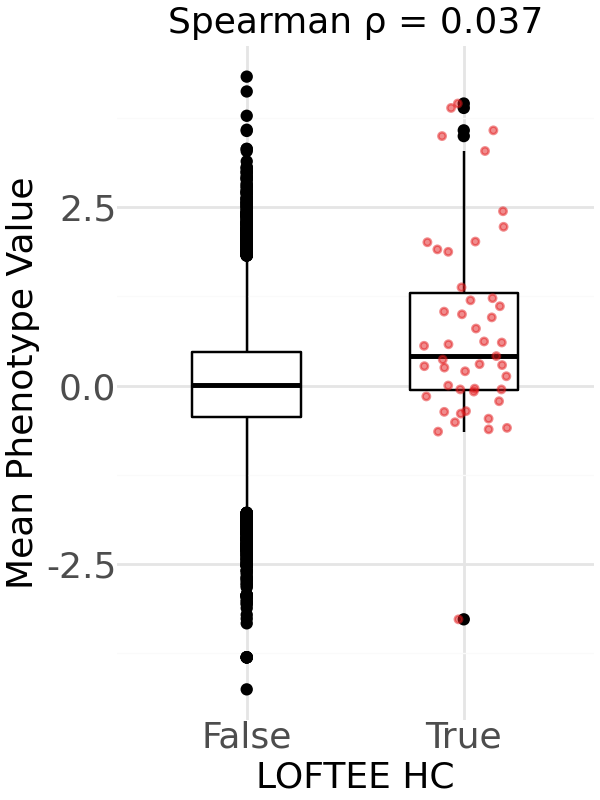

In [78]:
# LOFTEE HC box plot
loftee_anno = 'loftee_hc'
_loftee_row = anno_config_df.filter(pl.col('annotation') == loftee_anno)
loftee_color = _loftee_row['color'][0]
loftee_label = _loftee_row['label'][0]

box_df = (
    pheno_plot_df
    .select(['id', loftee_anno, 'mean_pheno_value'])
    .drop_nulls()
    .with_columns(
        group = pl.when(pl.col(loftee_anno) == 1).then(pl.lit('True')).otherwise(pl.lit('False'))
    )
)

# Spearman correlation
rho, pval = spearmanr(
    box_df[loftee_anno].to_numpy(),
    box_df['mean_pheno_value'].to_numpy()
)
print(f"Spearman ρ = {rho:.3f} (p = {pval:.2e})")

(
    ggplot(box_df, aes(x='group', y='mean_pheno_value'))
    + geom_boxplot(color='black', width=0.5)
    + geom_jitter(aes(color='group', alpha='group'), width=0.2, size=1)
    + scale_color_manual(values={'False': 'black', 'True': loftee_color})
    + scale_alpha_manual(values={'False': 0, 'True': 0.5})
    + labs(
        x=loftee_label,
        y='Mean Phenotype Value',
        title=f'Spearman ρ = {rho:.3f}',
    )
    + theme_minimal()
    + theme(
        figure_size=(3, 4),
        legend_position='none',
        title=element_text(size=13, lineheight=1.4),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13, lineheight=1.4),
        plot_background=element_rect(fill="white", color="white"),
    )
)

# Pheno scatter plot

In [20]:
RAP_APPV_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/avg_pheno_per_var"
LOCAL_APPV_DIR = "/home/dnanexus/data_dir"

APPV_FILE = "quant_pheno_INT_loftee_mac20_EURunrelated_miss20per_appv_small.parquet"

!dx download {RAP_APPV_DIR}/{APPV_FILE} -o {LOCAL_APPV_DIR}/{APPV_FILE}
pheno_appv = pl.scan_parquet(f"{LOCAL_APPV_DIR}/{APPV_FILE}")

# Filter to variants in annotation set and low MAC
anno_keys = anno.select(pl.col('id').unique()).lazy()

pheno_appv = (
    pheno_appv
    .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        (pl.col('n_individuals') <= mac)
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value', 'n_individuals']
    )
    .collect(engine='streaming')
)

pheno_appv

Error: path "/home/dnanexus/data_dir/quant_pheno_INT_loftee_mac20_EURunrelated
_miss20per_appv_small.parquet" already exists but -f/--overwrite was not set


id,phenotype,mean_pheno_value,n_individuals
str,str,f32,i32
"""chr2:21014794:C:T""","""cholesterol_int""",-0.314186,7
"""chr2:21024629:A:C""","""vitamin_d_int""",-0.066045,5
"""chr2:21024629:A:C""","""cholesterol_int""",0.367438,5
"""chr2:21024629:A:C""","""creatinine_int""",-0.762991,5
"""chr2:21019974:GGGTGCAA:G""","""alanine_aminotransferase_int""",-1.304088,7
…,…,…,…
"""chr2:21045674:C:T""","""cholesterol_int""",-0.296104,2
"""chr2:21010186:C:T""","""ldl_direct_int""",-1.135112,3
"""chr2:21045674:C:T""","""standing_height_int""",0.835483,2
